# Laplacian filter on a galaxy image, keeping color (pure Julia notebook)

**Kernel:** select a **Julia** kernel (IJulia) in VS Code.

The image is loaded as **RGB**, so `imfilter` runs the Laplacian on each color channel separately and the edges keep their color (as in the butterfly example).

https://esahubble.org/images/heic2018b/

https://esahubble.org/images/archive/category/galaxies/

In [1]:
# One-time install: only adds packages that are missing
using Pkg
needed = ["Images", "ImageFiltering", "FileIO", "ImageIO", "MosaicViews"]
installed = Set(p.name for p in values(Pkg.dependencies()) if p.is_direct_dep)
missing_pkgs = filter(p -> !(p in installed), needed)
isempty(missing_pkgs) || Pkg.add(missing_pkgs)
println("Julia ", VERSION, " | working dir: ", pwd())

Julia 1.12.7 | working dir: /Volumes/SSD2/MyJulia/Galaxy Laplacian
.12.7 | working dir: /Volumes/SSD2/MyJulia/Galaxy Laplacian


In [2]:
using Images, ImageFiltering, FileIO, MosaicViews, Statistics

# --- Set this to your galaxy image (PNG/JPG/TIFF); relative paths are relative to the notebook folder ---
path = "heic2018b.jpg"

function synthetic_galaxy(n=512)
    g = zeros(Float32, n, n)
    for j in 1:n, i in 1:n
        x, y = (i - n/2) / (n/2), (j - n/2) / (n/2)
        r, θ = hypot(x, y), atan(y, x)
        disk  = exp(-r / 0.35)
        arms  = 0.5 + 0.5 * cos(2θ - 7 * log(r + 1e-3))
        bulge = 1.5 * exp(-(r / 0.08)^2)
        g[i, j] = clamp(disk * (0.4 + 0.6 * arms) + bulge + 0.02 * randn(), 0, 1)
    end
    # simple warm-core / blue-arm tint so the demo has color
    return RGB{Float32}.(g .^ 0.8, g, min.(g .* 1.2, 1))
end

if isfile(path)
    img = RGB{Float32}.(load(path))     # keep color (no Gray conversion)
else
    @warn "$path not found in $(pwd()) - using a synthetic spiral galaxy instead"
    img = synthetic_galaxy()
end
size(img)

(3920, 3657)

## Brighter version
The raw Laplacian is signed and mostly small, so it looks dark. This takes the magnitude of each channel and stretches it. Lower `pct` (e.g. 0.99) for a brighter result, raise it (e.g. 0.9999) to keep only the sharpest edges.

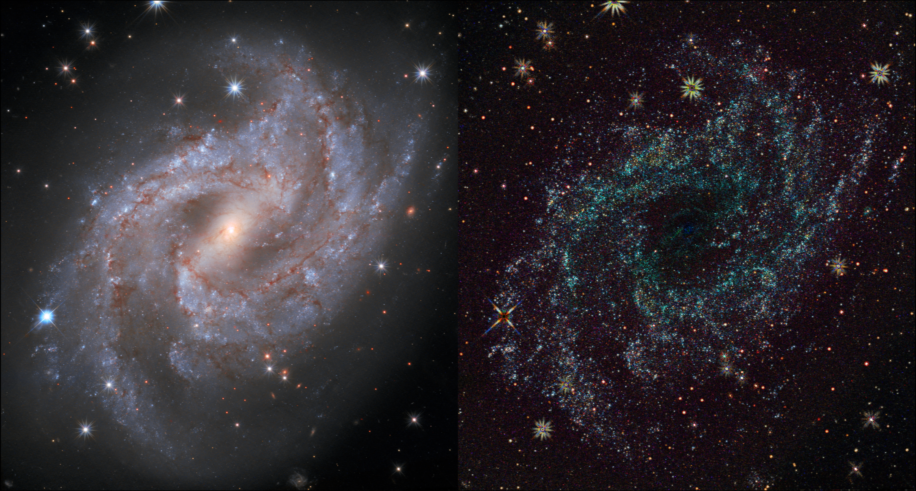

In [3]:
σ = 3                                          # try 2–5; larger = coarser structure
imglog = imfilter(img, Kernel.LoG(σ))
B = abs.(Float32.(channelview(imglog)))
for c in 1:3                                   # scale each channel on its own
    B[c, :, :] ./= quantile(vec(B[c, :, :]), 0.995)
end
imglog_vis = colorview(RGB, clamp.(B, 0f0, 1f0))
mosaicview(img, imglog_vis; nrow=1)

### σ = 1

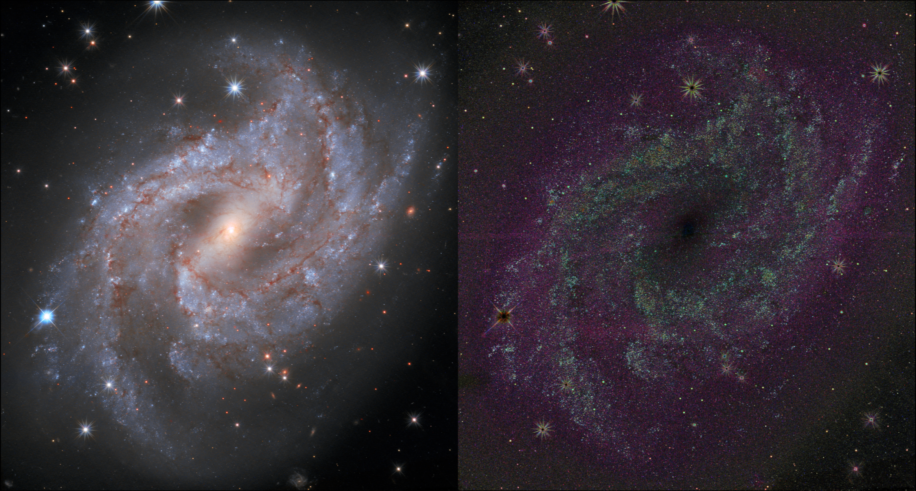

### σ = 2

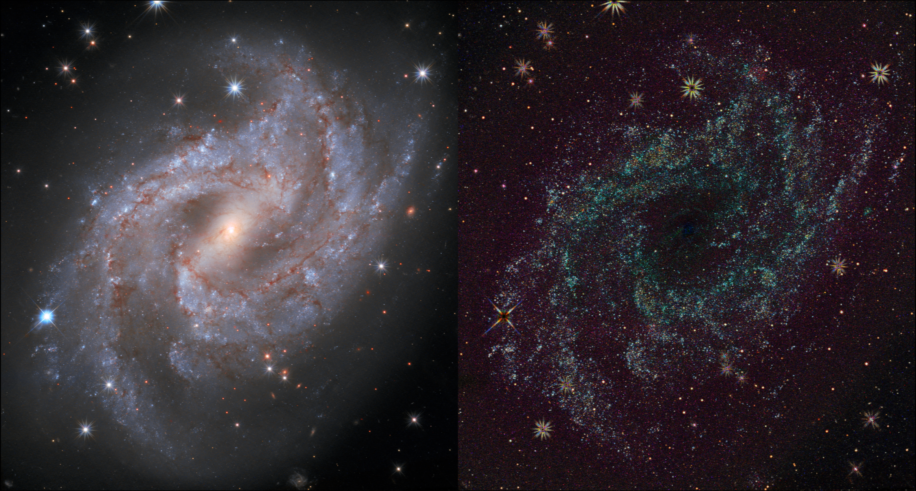

### σ = 4

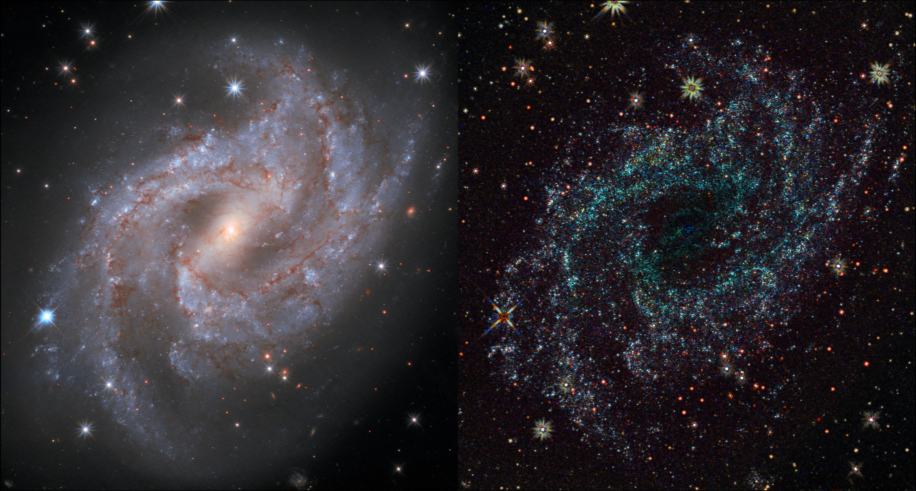

### σ = 8

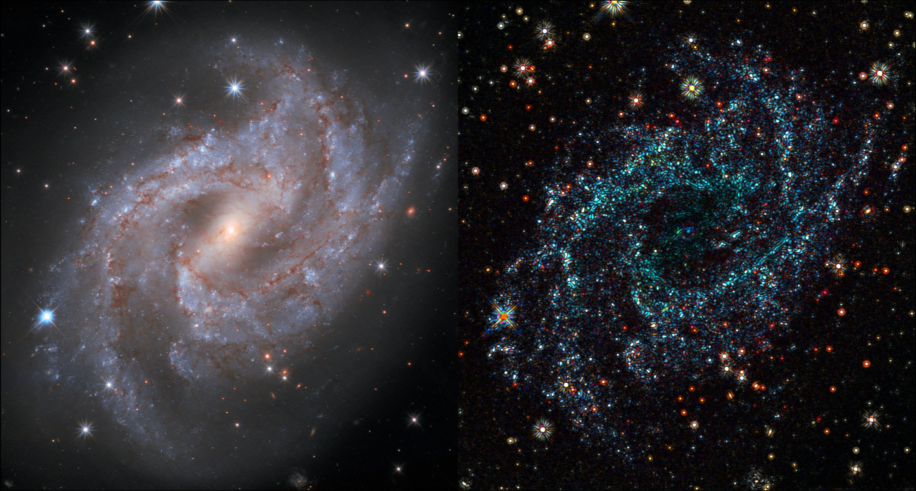

### σ = 16

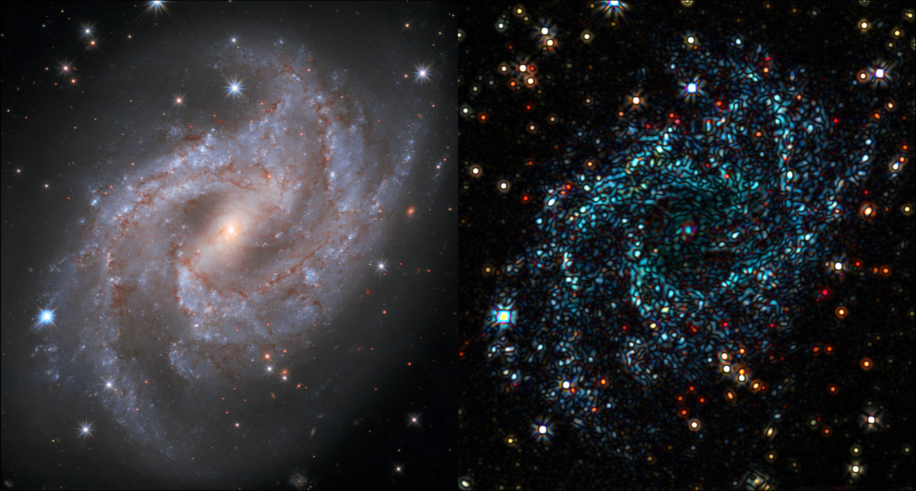

In [4]:
#σs = 2:5                                       # larger σ = coarser structure
σs = [1, 2, 4, 8, 16]

function log_vis(img, σ; pct=0.995)
    imglog = imfilter(img, Kernel.LoG(σ))
    B = abs.(Float32.(channelview(imglog)))
    for c in 1:3                               # scale each channel on its own
        B[c, :, :] ./= quantile(vec(B[c, :, :]), pct)
    end
    return colorview(RGB, clamp.(B, 0f0, 1f0))
end

for σ in σs
    p = log_vis(img, σ)
    display("text/markdown", "### σ = $σ")     # title above each pair
    display(mosaicview(img, p; nrow=1))        # left: original   right: LoG
end

### Original  |  LoG (σ = 8)

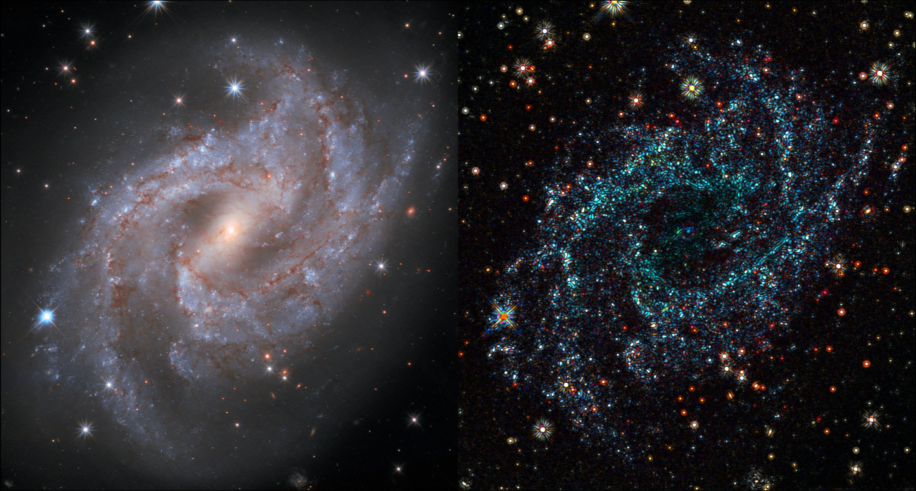

In [5]:
using Images, ImageFiltering, MosaicViews, Statistics

# LoG magnitude, each channel stretched on its own
function log_vis(img, σ; pct=0.995)
    B = abs.(Float32.(channelview(imfilter(img, Kernel.LoG(σ)))))
    for c in 1:3
        B[c, :, :] ./= quantile(vec(B[c, :, :]), pct)
    end
    return colorview(RGB, clamp.(B, 0f0, 1f0))
end

σ_log = 8
display("text/markdown", "### Original  |  LoG (σ = $σ_log)")
mosaicview(img, log_vis(img, σ_log); nrow=1)

LoG, σ = 8 (original | LoG)

What it highlights

Compact bright structures about 20 px across at full resolution. 
A LoG responds most to blobs of radius about σ√2, roughly 11 px here. 
That fits star clusters, HII regions and star-forming knots, which appear as dense teal speckle tracing the spiral arms.

Faint outer arm segments. The stretched streaks on the right side are much easier to follow than in the original, 
because the filter removes the smooth glow and keeps the clumpy structure.

Foreground stars and red point sources. These appear as small orange and white dots scattered over the field and well outside the galaxy. 
They are separated cleanly from the blue arm structure, which isn't obvious in the original.

The blue/orange split. The arms are teal and the isolated point sources are orange. Part of this is a stretching effect (below), 
but it does show that the blue and green channels carry the arm clumps and the red channel carries the isolated stars.


What it does not highlight

The bar, bulge and diffuse light. 
The center is nearly black, because a smooth brightness gradient has almost no second derivative.

Dust lanes as lanes. The filter shows only where brightness changes at the blob scale, so a dust lane shows up as a dark gap between speckles 
and not as a feature. The rust-colored lanes in the original are essentially gone.

Sign and brightness. I take the absolute value, so a bright clump and a dark hole look the same, and bright regions are not brighter.

True color. Each channel is stretched on its own, so the teal and orange palette reflects relative channel strength and not real color.


Artifacts to be aware of

Bright stars become colored rings and starbursts, and the blue star on the left shows a colored X with an orange core.

At larger σ, such as 16, the filter produces worm-like texture that isn't real structure.


How they complement each other

LoG σ = 8	Scharr σ = 4

Responds to	Blob cores (second derivative)	Edges and steps (first derivative)
Spiral-arm tracing	Better, continuous teal ribbons	Weaker, broken into outlines
Dust lanes	Not visible	Visible as filaments
Color	Artificial, per-channel stretch	Close to the original
Noise	Cleaner background	Slightly more speckle
Bulge, bar, diffuse glow	Dark	Dark


### Original  |  Scharr gradient, luminance with original color (pre-blur σ = 4)

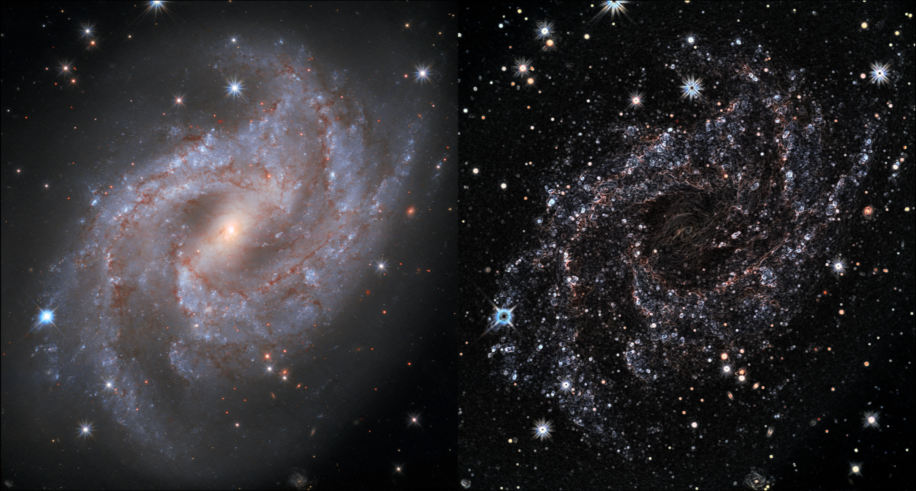

In [6]:
function scharr_lum_color(img, σ; pct=0.995)
    lum = Float32.(Gray.(img))
    gy, gx = imgradients(imfilter(lum, Kernel.gaussian(σ)), KernelFactors.scharr)
    m = hypot.(gy, gx)
    v = clamp.(m ./ quantile(vec(m), pct), 0f0, 1f0)     # same as the grayscale result
    chroma = img ./ max.(lum, 0.05f0)                    # original color, brightness removed
    return clamp01.(chroma .* v)
end

σ_scharr = 4
display("text/markdown", "### Original  |  Scharr gradient, luminance with original color (pre-blur σ = $σ_scharr)")
mosaicview(img, scharr_lum_color(img, σ_scharr); nrow=1)

Scharr gradient, luminance with original color, pre-blur σ = 4 (original | Scharr)

What it highlights

Boundaries of features, not their cores. 
The clumps appear as small bubbles, rings and shells outlining clusters and star-forming complexes. This is the clearest difference from the LoG, which marks the middles of the same objects.

Dust filaments. 
Thin rust-colored curls and threads show near the center and along the inner arms. They are the edges of dust lanes, and they are almost invisible in the LoG.

Real object colors. 
The color comes from the original, so blue-white clusters, orange stars and rust-colored dust edges keep believable colors. Per-channel stretching is no longer involved, which is why this version looks more natural.

Cluster-to-gap contrast. 
Wherever a clump meets the darker space between arms, the edge lights up, so the inter-arm gaps show up clearly in outline.


What it does not highlight

Interiors. 
The centers of clusters and the smooth bulge and bar are dark, since flat or slowly varying regions have a small gradient.

Edge direction and polarity. 
A bright-to-dark edge and a dark-to-bright edge look the same, so you can't tell which side of a dust lane is brighter.

Faint outer arm segments. 
They are less continuous than in the LoG, because only steep changes register.

Chroma detail. 
Color is taken from the luminance-normalized original and then applied only at edge pixels, so color information away from edges is lost, and the 0.05 floor on luminance slightly mutes color in the darkest areas.


Artifacts to be aware of

Saturated stars appear as rings with dark centers, because their flat tops have no gradient.

The result depends on the pre-blur. σ = 4 gives bubble outlines, while σ = 1 or 2 mostly shows fine grain.
